In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

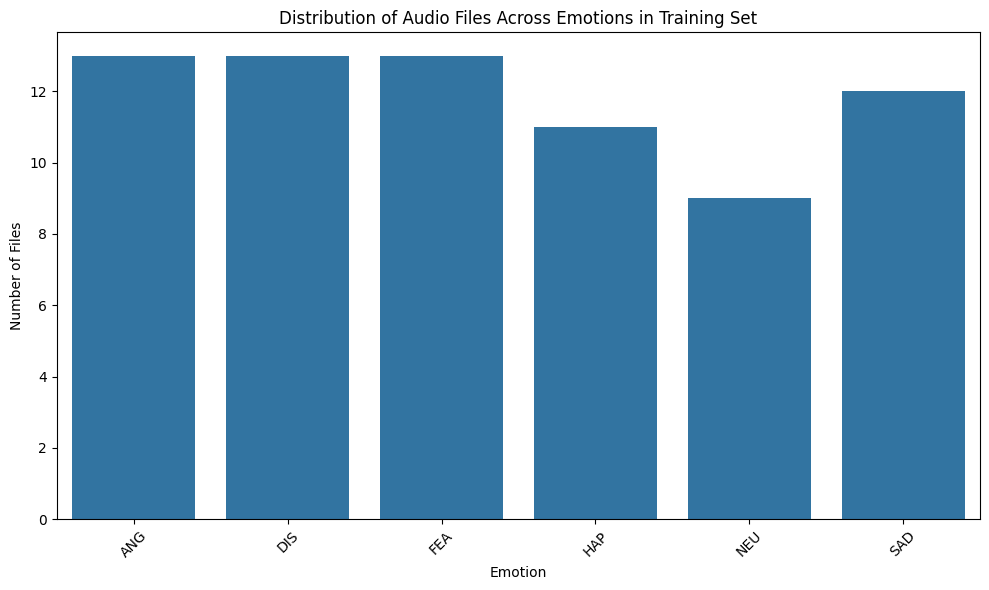


Summary Statistics:
Total number of audio files: 71

Files per emotion:
ANG: 13
DIS: 13
FEA: 13
HAP: 11
NEU: 9
SAD: 12


In [3]:
EMOTIONS = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

emotion_counts = {}
for emotion in EMOTIONS:
    emotion_path = os.path.join('..', '..', 'data', 'train', emotion)
    emotion_counts[emotion] = len(os.listdir(emotion_path))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()))
plt.title('Distribution of Audio Files Across Emotions in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Number of Files')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print(f"Total number of audio files: {sum(emotion_counts.values())}")
print("\nFiles per emotion:")
for emotion, count in emotion_counts.items():
    print(f"{emotion}: {count}")


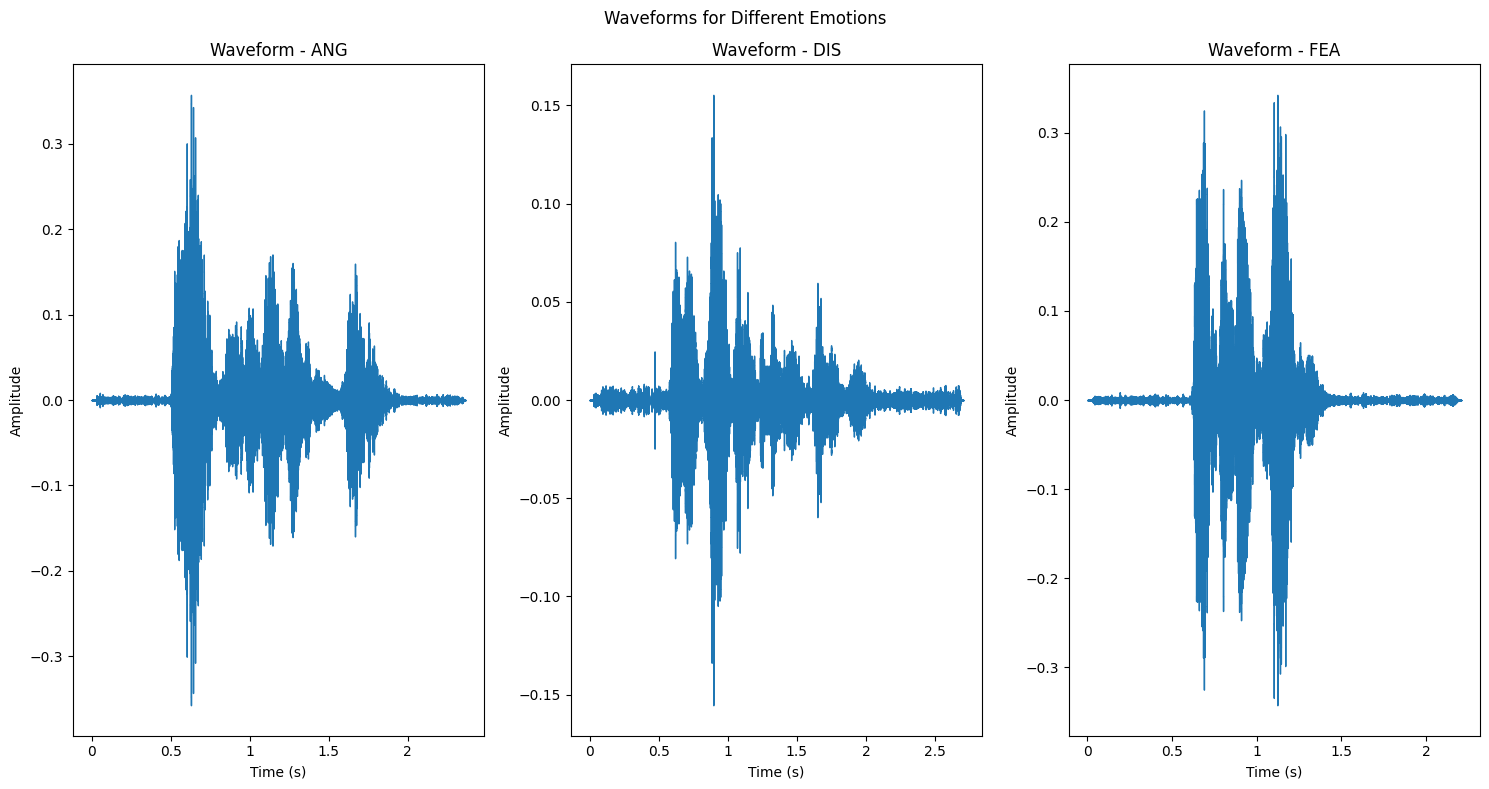

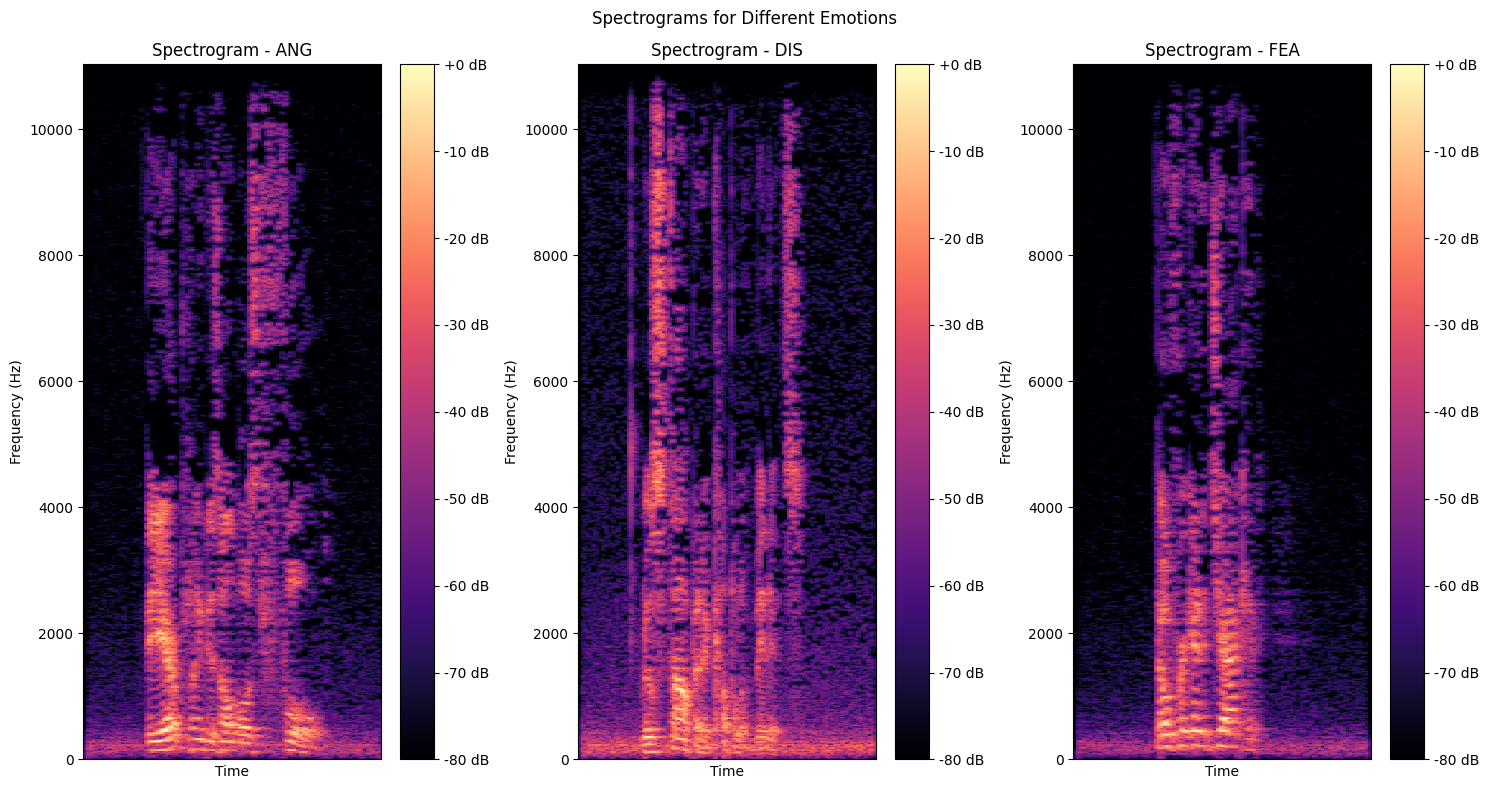

In [13]:
sample_files = {}
for emotion in EMOTIONS[:3]:
    emotion_path = os.path.join('..', '..', 'data', 'train', emotion)
    sample_files[emotion] = os.listdir(emotion_path)[0]

fig_wave, axes_wave = plt.subplots(1, 3, figsize=(15, 8))
waveform_axes = [axes_wave[0], axes_wave[1], axes_wave[2]]

# plot sample waveform for each emotion
for i, (emotion, filename) in enumerate(sample_files.items()):
    audio_path = os.path.join('..', '..', 'data', 'train', emotion, filename)
    y, sr = librosa.load(audio_path)
    
    if i < len(waveform_axes):
        librosa.display.waveshow(y, sr=sr, ax=waveform_axes[i])
    else:
        print(f"Warning: Not enough axes for emotion {emotion}")
    waveform_axes[i].set_title(f'Waveform - {emotion}')
    waveform_axes[i].set_xlabel('Time (s)')
    waveform_axes[i].set_ylabel('Amplitude')

plt.suptitle('Waveforms for Different Emotions')
plt.tight_layout()
plt.show()

fig_spec, axes_spec = plt.subplots(1, 3, figsize=(15, 8))
spec_axes = [axes_spec[0], axes_spec[1], axes_spec[2]]

# Plot sample spectrogram for each emotion
for i, (emotion, filename) in enumerate(sample_files.items()):
    audio_path = os.path.join('..', '..', 'data', 'train', emotion, filename)
    y, sr = librosa.load(audio_path)
    
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, y_axis='linear', ax=spec_axes[i])
    spec_axes[i].set_title(f'Spectrogram - {emotion}')
    spec_axes[i].set_xlabel('Time')
    spec_axes[i].set_ylabel('Frequency (Hz)')
    fig_spec.colorbar(img, ax=spec_axes[i], format='%+2.0f dB')

plt.suptitle('Spectrograms for Different Emotions')
plt.tight_layout()
plt.show()


In [14]:
from IPython.display import Audio 

# play a sample audio
audio_path = os.path.join('..', '..', 'data', 'train', 'ANG', sample_files['ANG'])
print("Sample angry audio: ", audio_path)
Audio(audio_path, autoplay=True)

Sample angry audio:  ../../data/train/ANG/1001_TAI_ANG_XX.mp3


# Sample Spectogram Saved to Image

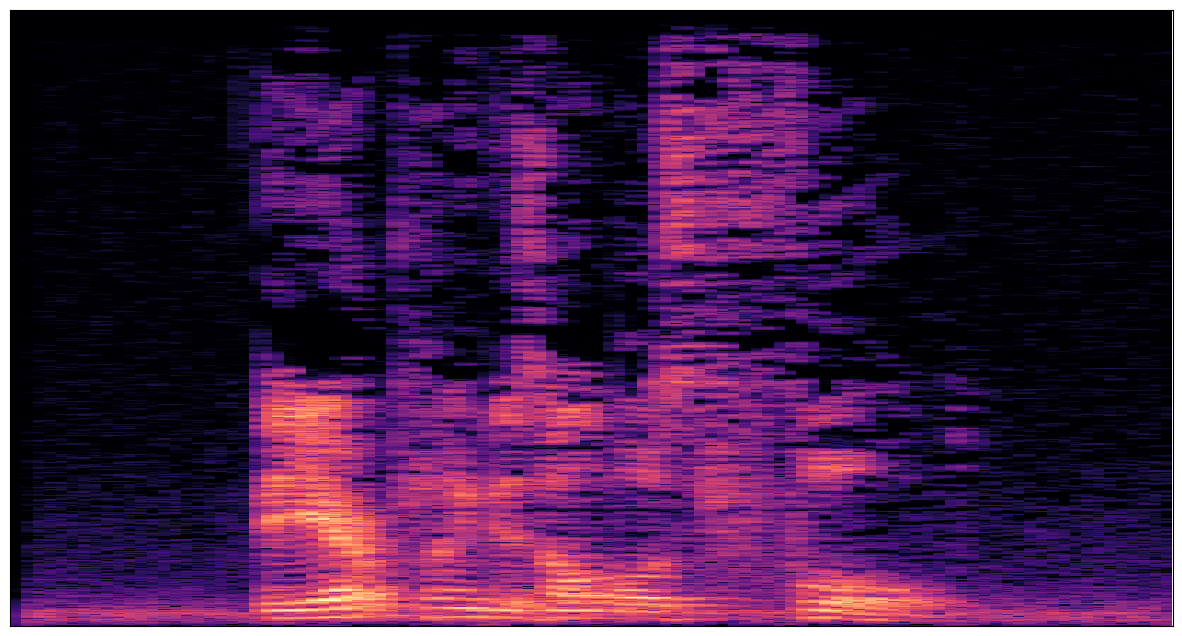

In [15]:
y, sr = librosa.load(audio_path)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

fig_spec, axes_spec = plt.subplots(1, 1, figsize=(15, 8))

img = librosa.display.specshow(D, sr=sr, ax=axes_spec)
axes_spec.set_xticks([])
axes_spec.set_yticks([])

plt.savefig('spectrogram.png', bbox_inches='tight', dpi=300)
plt.show()

